In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os

In [274]:
online = pd.read_csv("thetaEEG_gpype_2back_-1580742246_20260701_150605.csv")
channel_8 = online[['Time',' Ch08']]
online

,Time,Ch01,Ch02,Ch03,Ch04,Ch05,Ch06,Ch07,Ch08,Ch09
0,0.000,199999.96875,0.002558,6.544805e-06,-5.184103,-0.103682,-0.467714,-0.139504,1.319924,0
1,0.004,199999.96875,0.037796,1.428505e-03,-2.845118,-0.160584,-0.526376,1.161708,9.285474,0
2,0.008,199999.96875,0.275688,7.600379e-02,-1.119165,-0.182968,-0.549451,2.492168,31.305298,0
3,0.012,199999.96875,1.332944,1.776740e+00,0.249624,-0.177975,-0.544304,4.145252,69.060768,0
4,0.016,199999.96875,4.838527,2.341134e+01,1.369426,-0.150587,-0.516069,5.700265,114.345558,0
...,...,...,...,...,...,...,...,...,...,...
15389,61.556,199999.96875,-0.000001,1.194370e-12,-11.922862,-12.346942,-13.089630,-13.089630,-1.621828,0
15390,61.560,199999.96875,-0.000001,1.227724e-12,-11.910899,-12.345981,-13.088638,-13.089630,-1.797366,0
15391,61.564,199999.96875,-0.000001,1.235019e-12,-11.908325,-12.341675,-13.084201,-13.089630,-1.850854,0
15392,61.568,199999.96875,-0.000001,1.216501e-12,-11.914886,-12.333303,-13.075569,-13.089630,-1.819626,0


In [275]:
import pandas as pd
import numpy as np

arrow = online[online[' Ch09'] == 38].copy()
filtered = []
last_time = -np.inf

for _, row in arrow.iterrows():
    t = row['Time']
    if t - last_time >= 5.0:   # keep only if greater than 5 seconds apart
        filtered.append(row)
        last_time = t

filtered_arrow = pd.DataFrame(filtered)

# Step 3: extract channel 8 values
channel_8_eeg = np.array(filtered_arrow[' Ch08'])

lifu_on_ts = np.array(filtered_arrow['Time'])
lifu_on_ts

array([ 6.132, 16.036, 25.492, 53.596])

In [287]:
# windowing ONLINE
windows = []
for idx, ts in enumerate(lifu_on_ts):
    window = online[abs(online['Time'] - ts) < 5]
    windows.append(window)
windows = np.array(windows)
windows.shape

(4, 2499, 10)

In [ ]:
# SAVE MY WINDOWSSSS

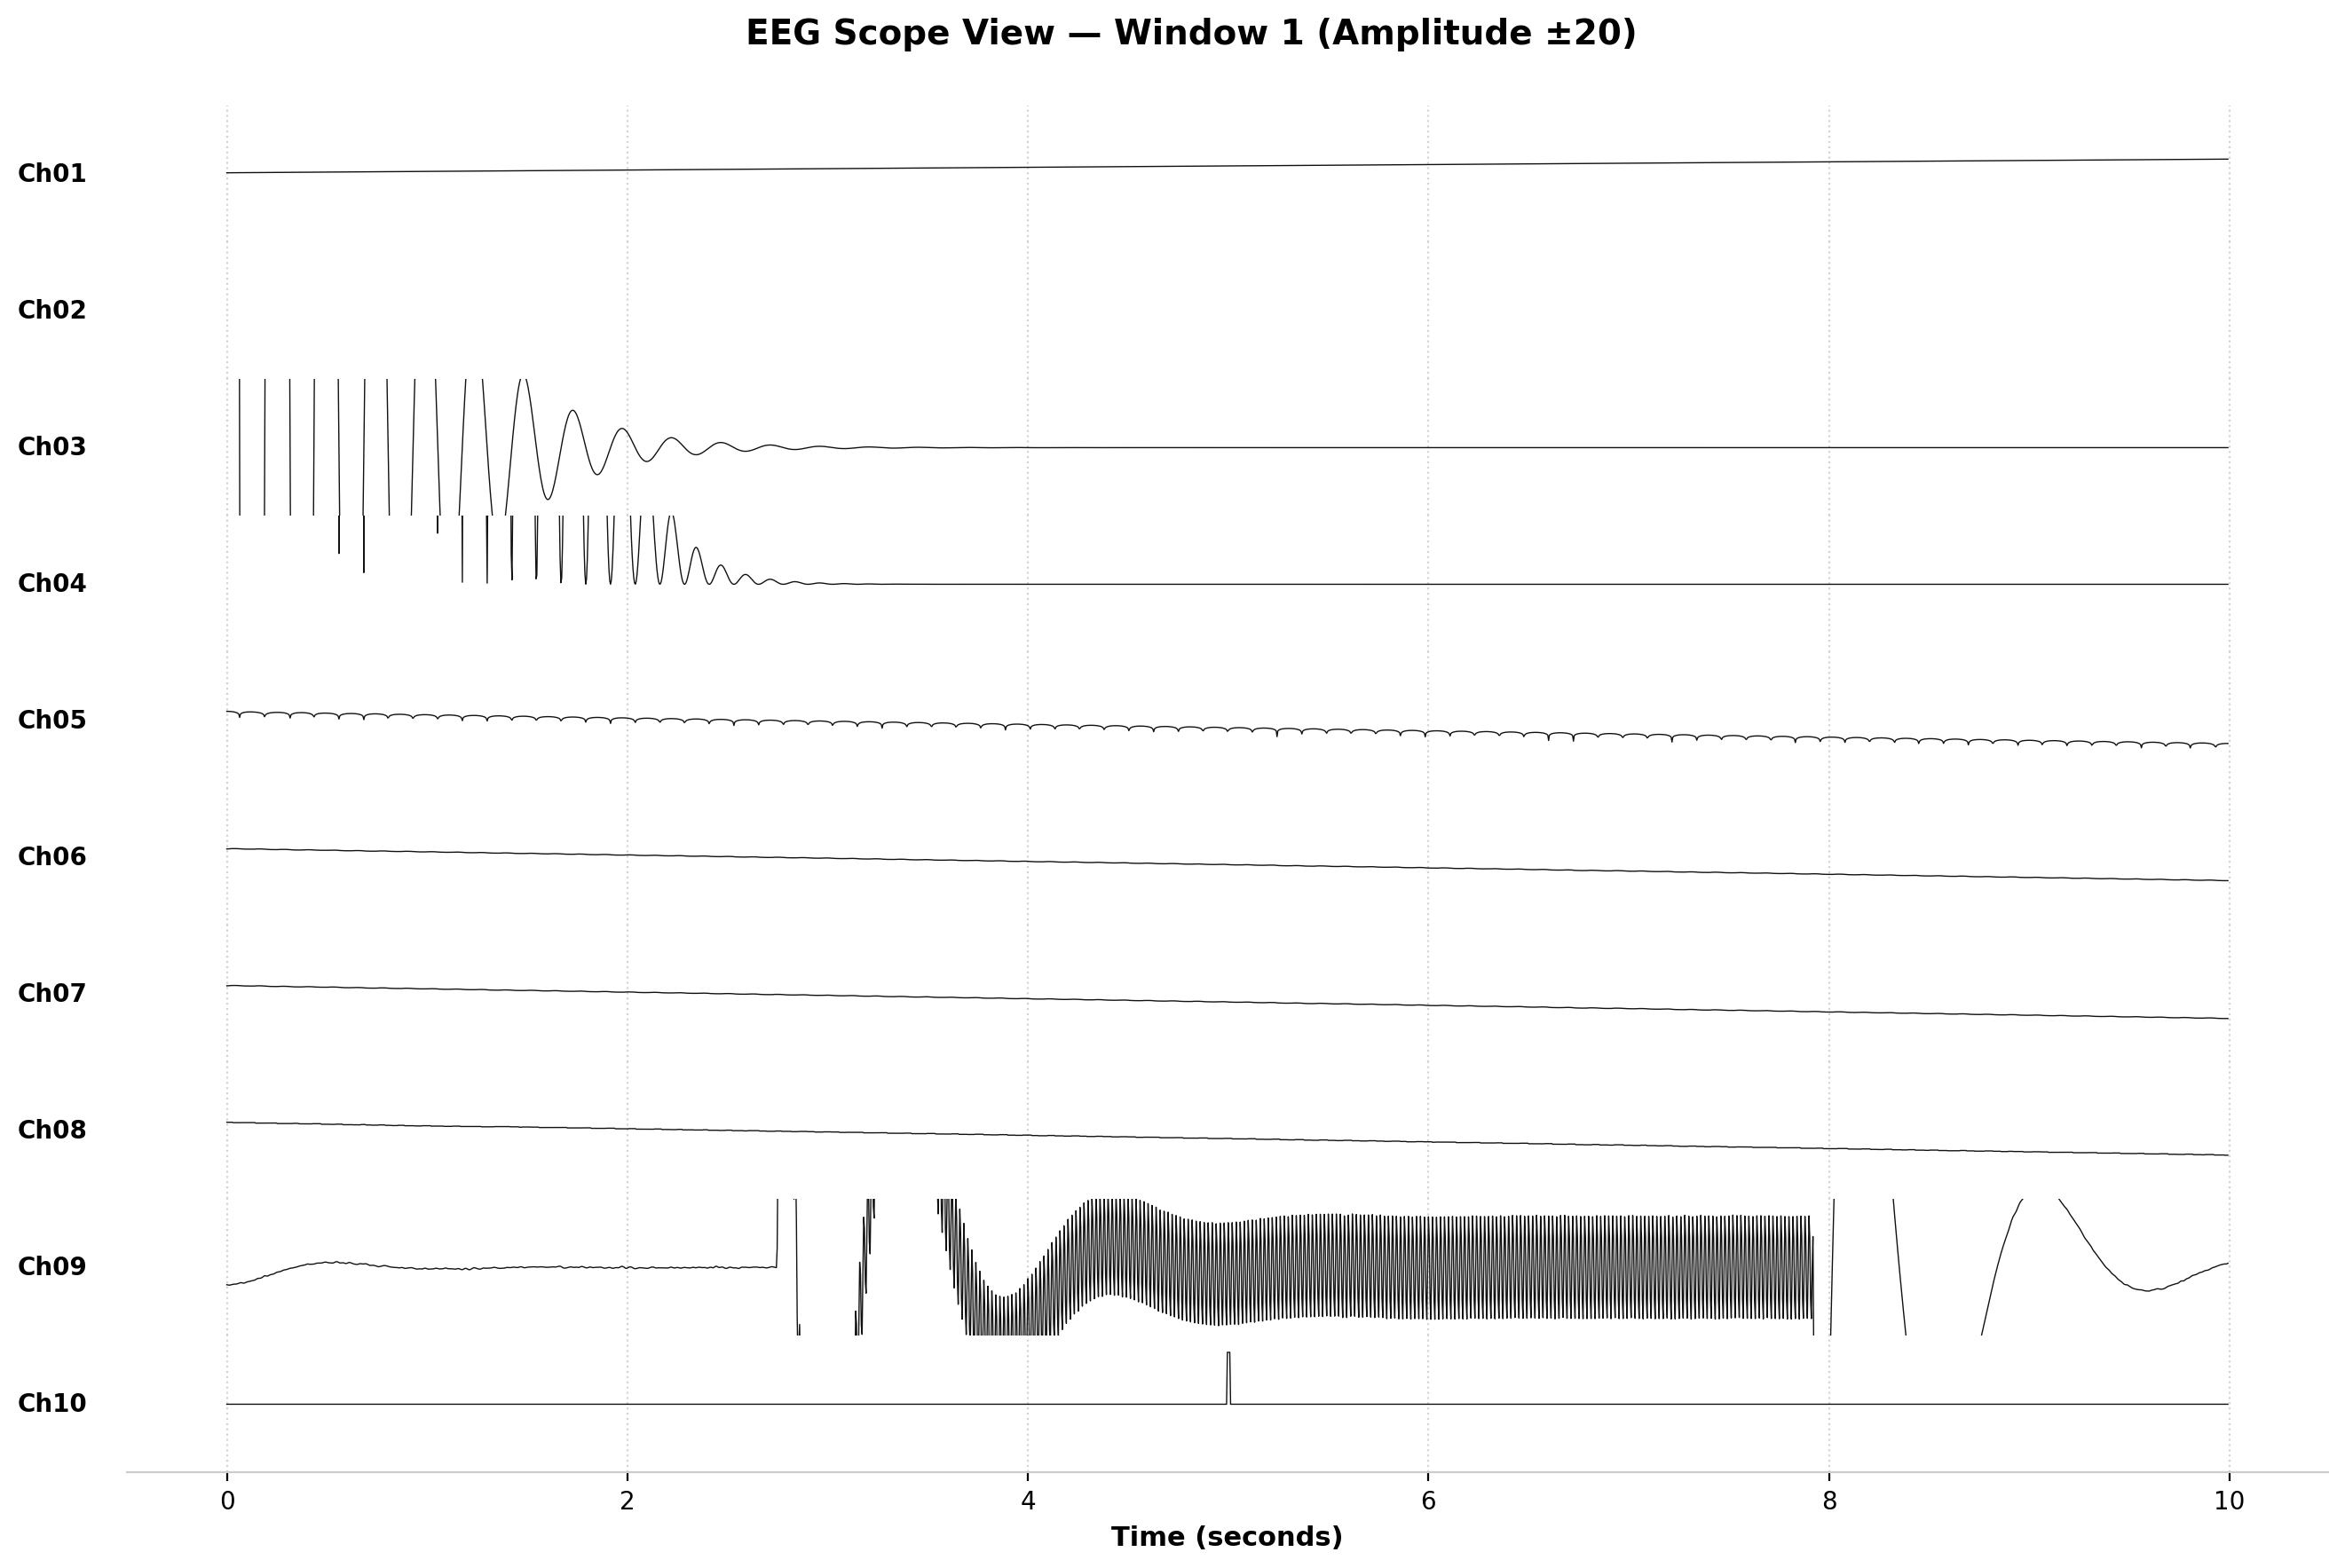

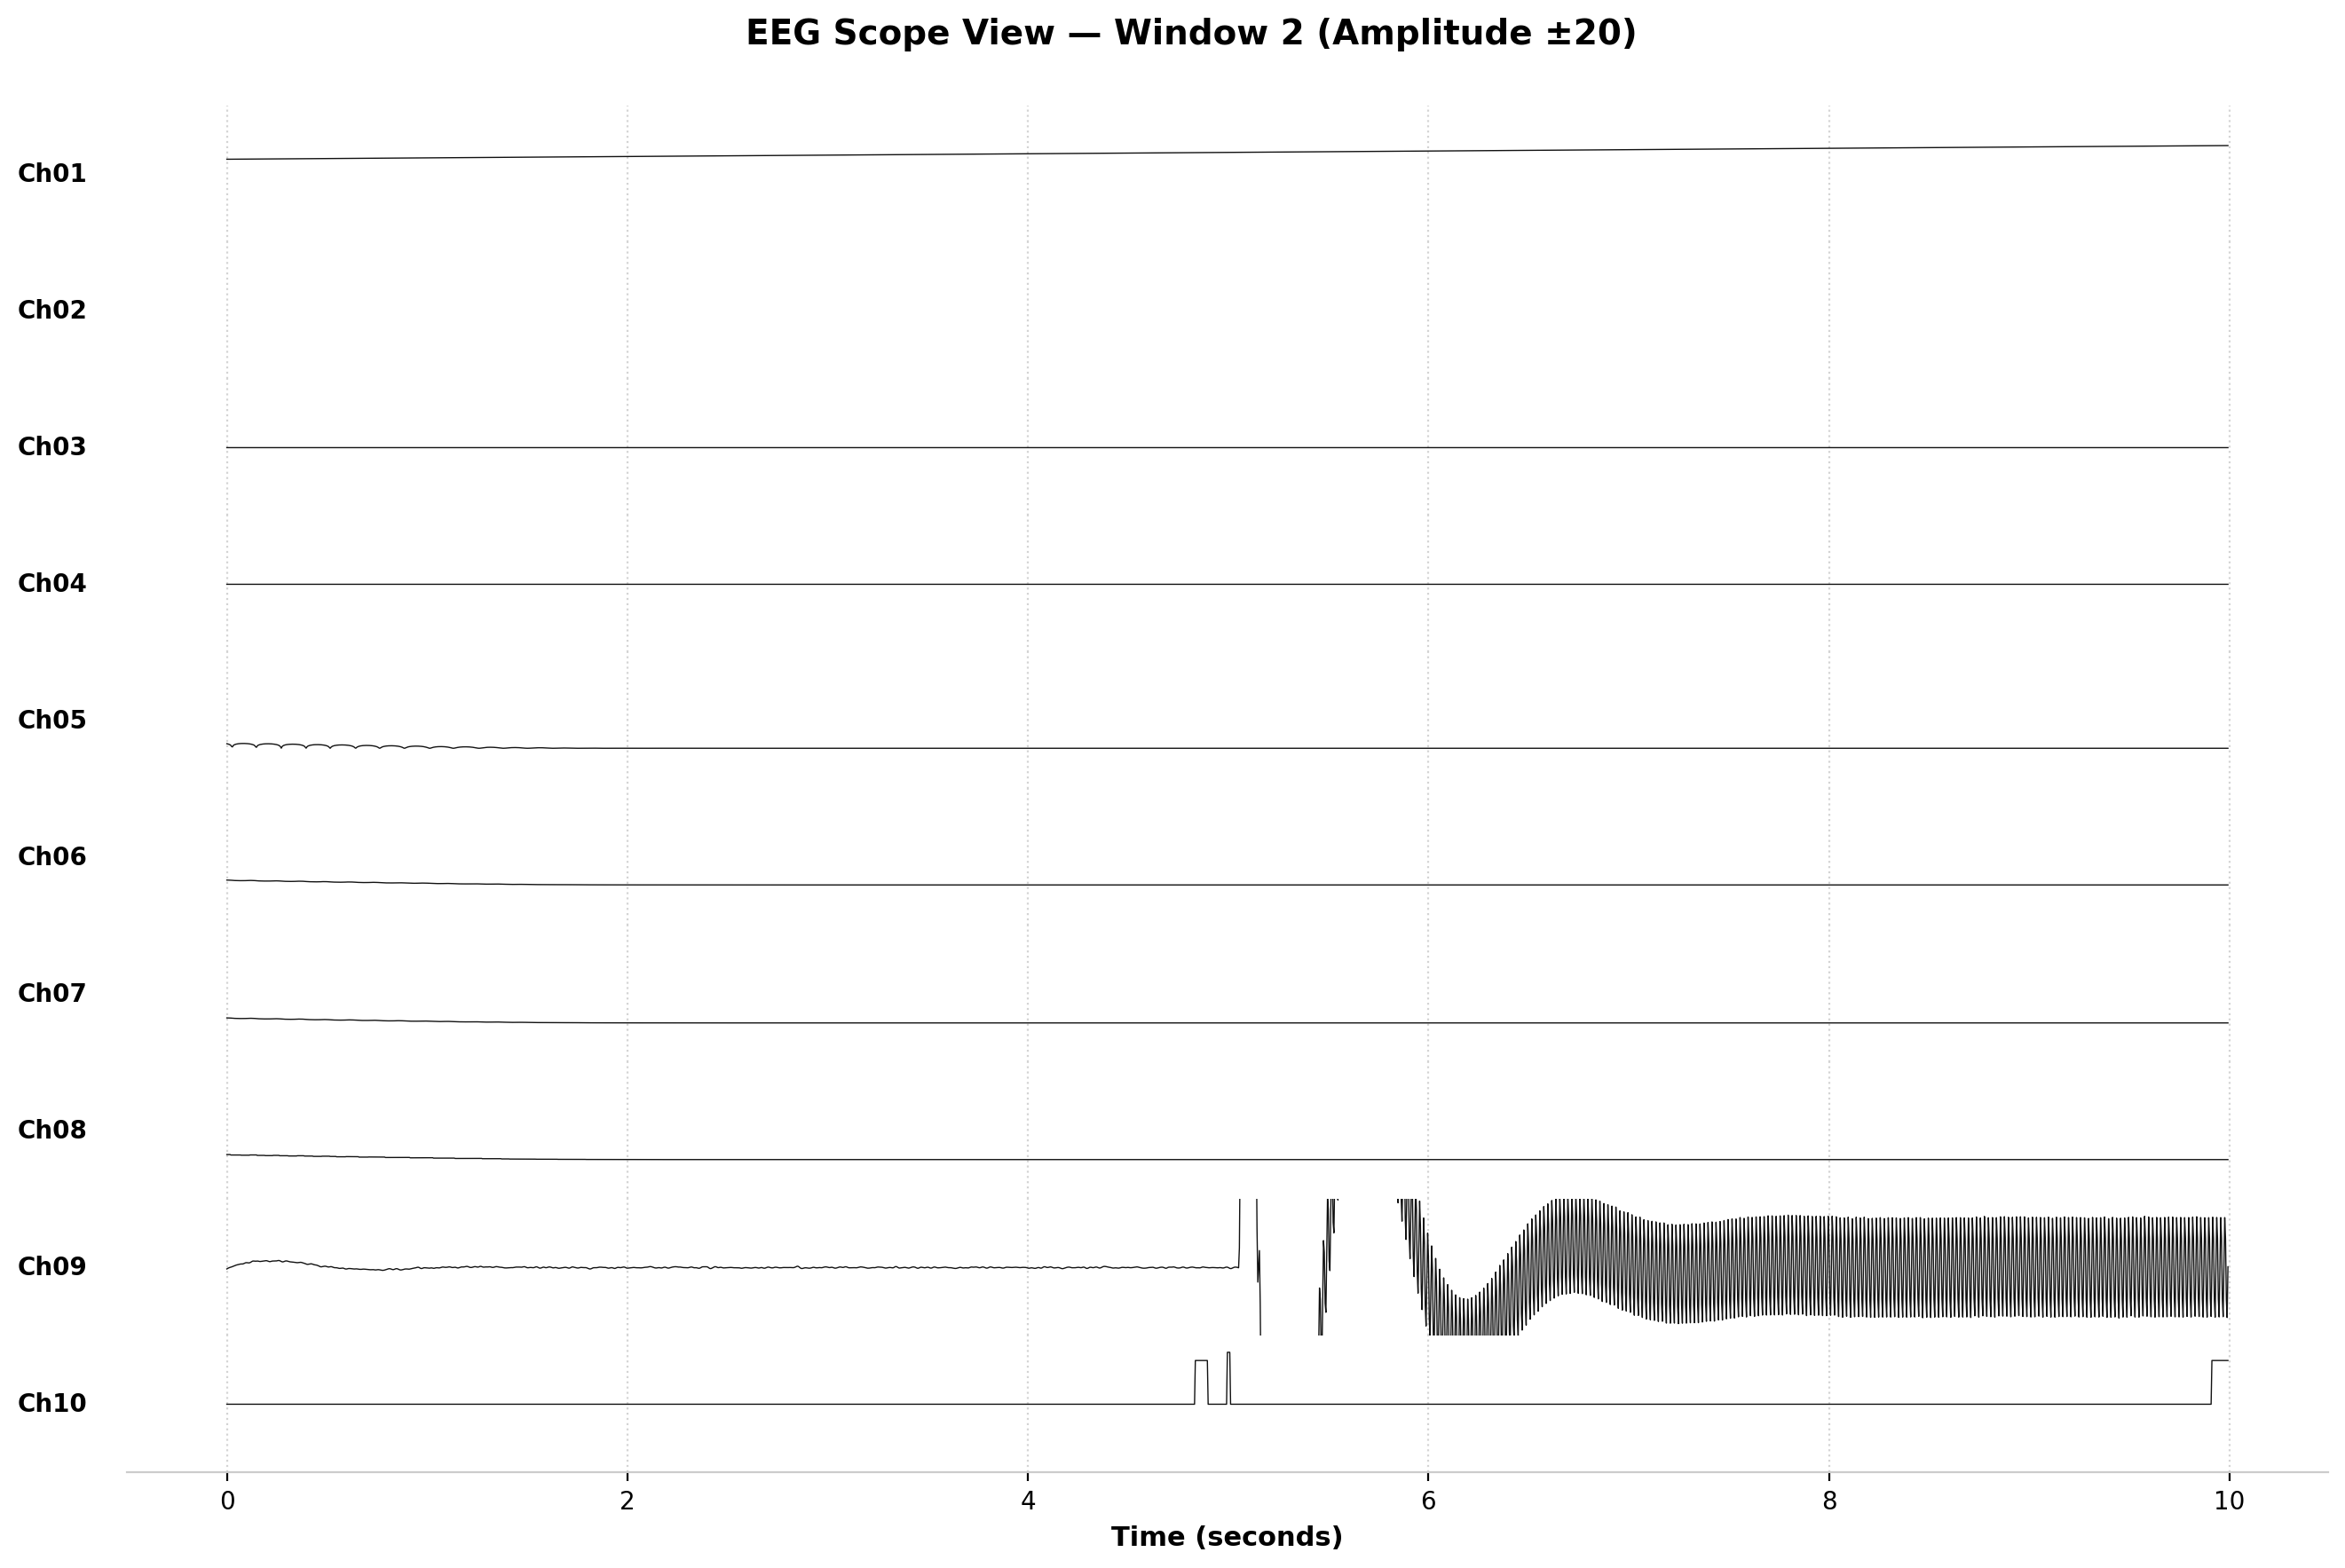

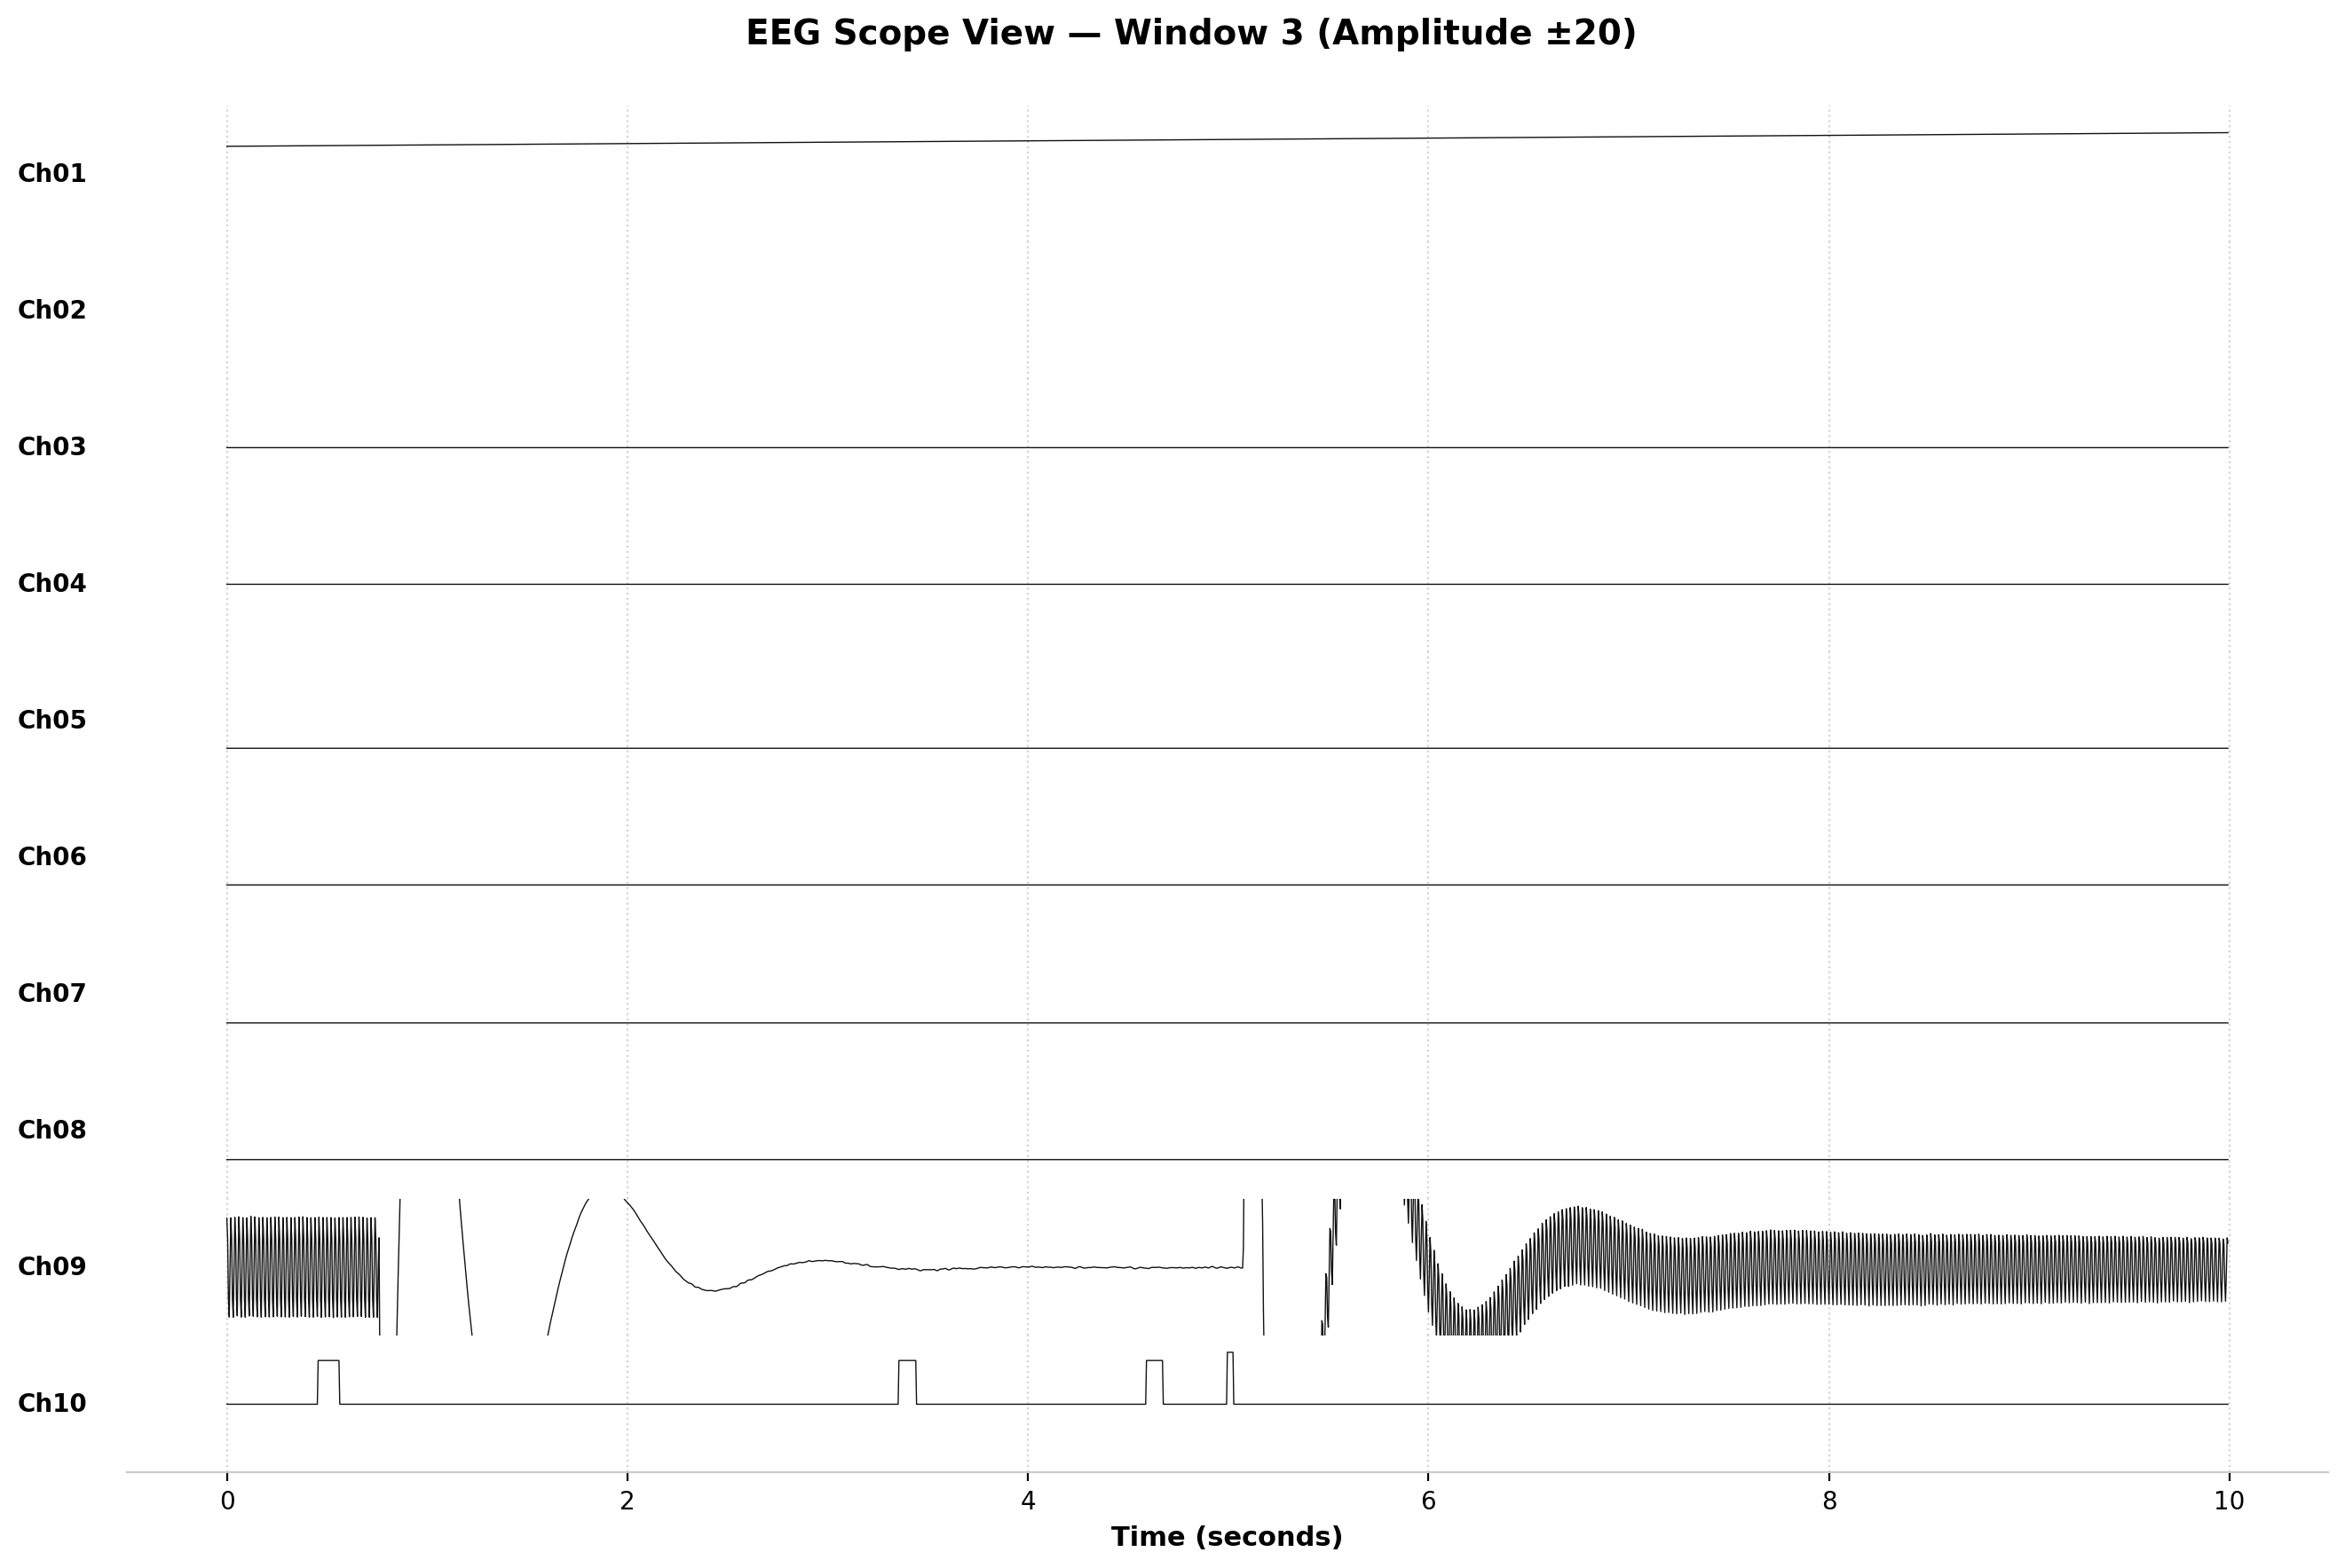

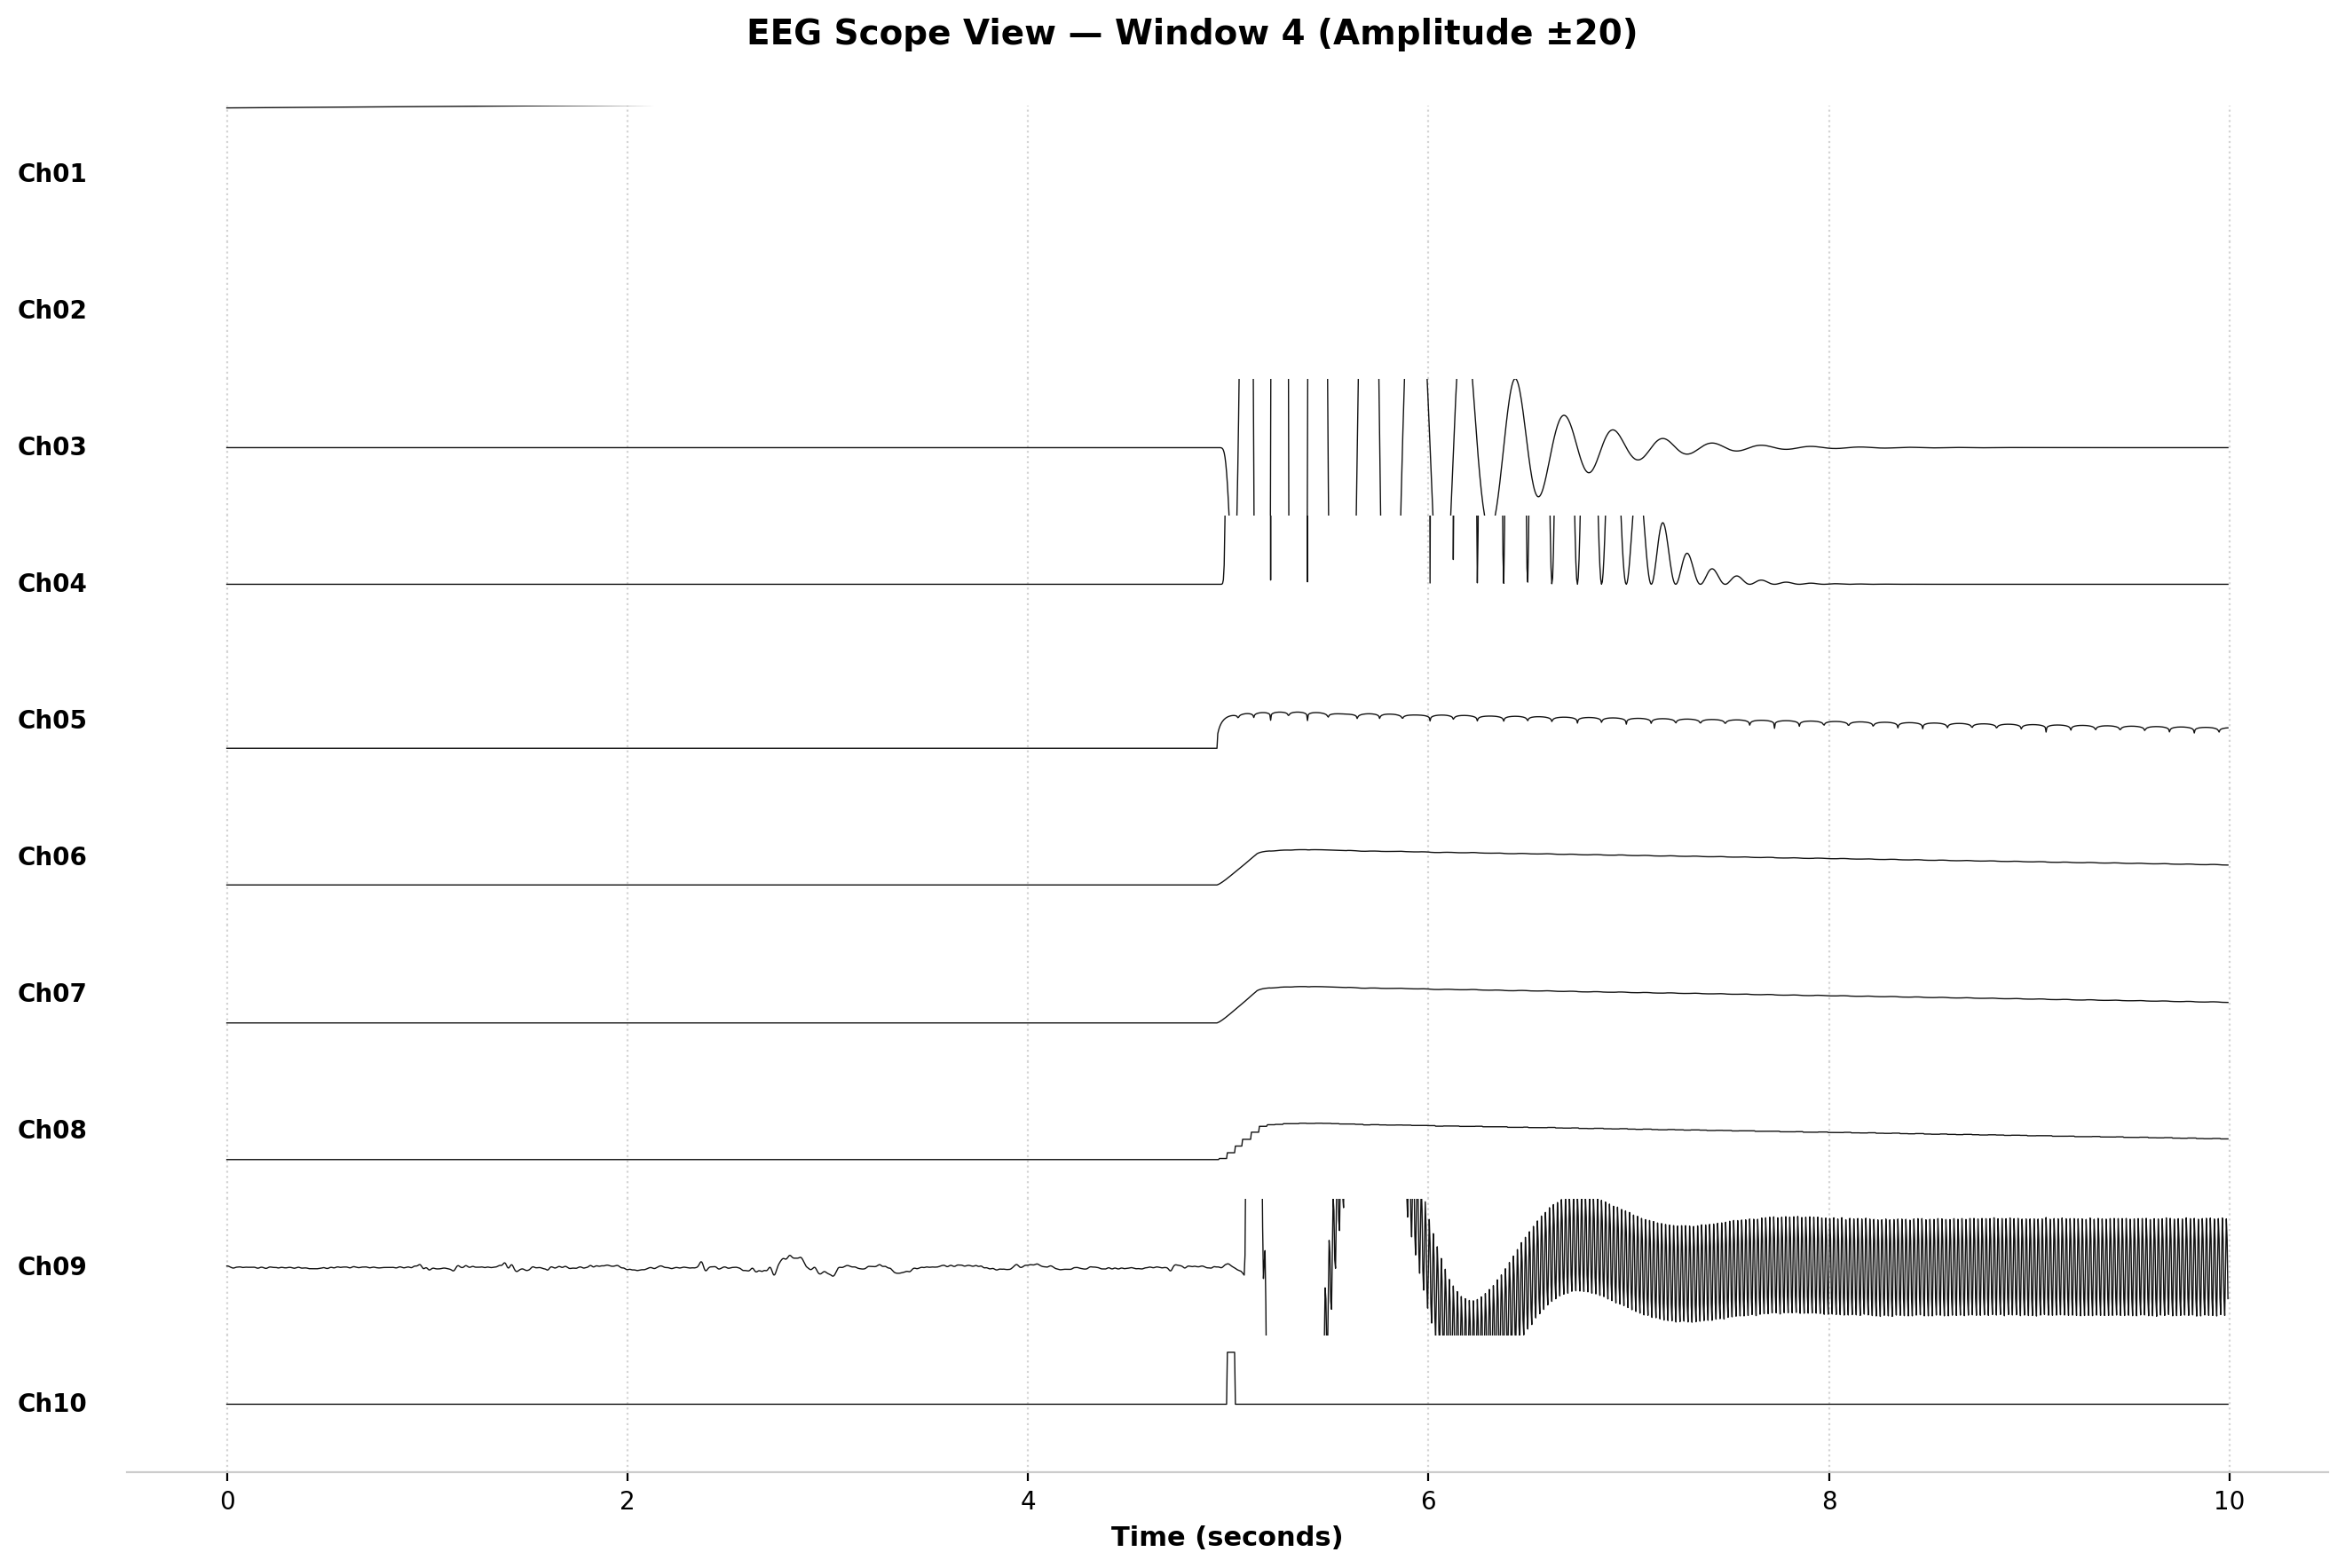

In [277]:
import numpy as np
import matplotlib.pyplot as plt

# windows: shape (4, 2250, 10)
# Example: windows = np.random.randn(4, 2250, 10)

n_windows = windows.shape[0]
n_times   = windows.shape[1]
n_channels = windows.shape[2]

AMPLITUDE_WINDOW = 50

# Time axis (assuming 250 Hz sampling)
fs = 250
time = np.arange(n_times) / fs

for w in range(n_windows):
    fig, axes = plt.subplots(n_channels, 1, figsize=(16, 10), sharex=True, dpi=200)
    
    for ch in range(n_channels):
        axes[ch].plot(time, windows[w, :, ch], color='#111111', linewidth=0.5)
        axes[ch].set_ylim(-AMPLITUDE_WINDOW, AMPLITUDE_WINDOW)
        axes[ch].set_ylabel(f"Ch{ch+1:02d}", rotation=0, labelpad=30,
                            verticalalignment='center', fontweight='bold')
        axes[ch].grid(True, linestyle=':', alpha=0.5, color='#aaaaaa')
        axes[ch].set_yticks([])
        
        for spine in ['top', 'right', 'left', 'bottom']:
            axes[ch].spines[spine].set_visible(False)

    axes[-1].spines['bottom'].set_visible(True)
    axes[-1].spines['bottom'].set_color('#cccccc')
    axes[-1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')

    plt.subplots_adjust(hspace=0.0)
    plt.suptitle(f'EEG Scope View — Window {w+1} (Amplitude ±20)', fontsize=14, fontweight='bold', y=0.93)
    plt.show()


In [279]:
# delay
small = []
for idx, df in enumerate(windows):
    df = windows[idx][1000:1500]
    small.append(df)
small = np.array(small)
small.shape

(4, 500, 10)

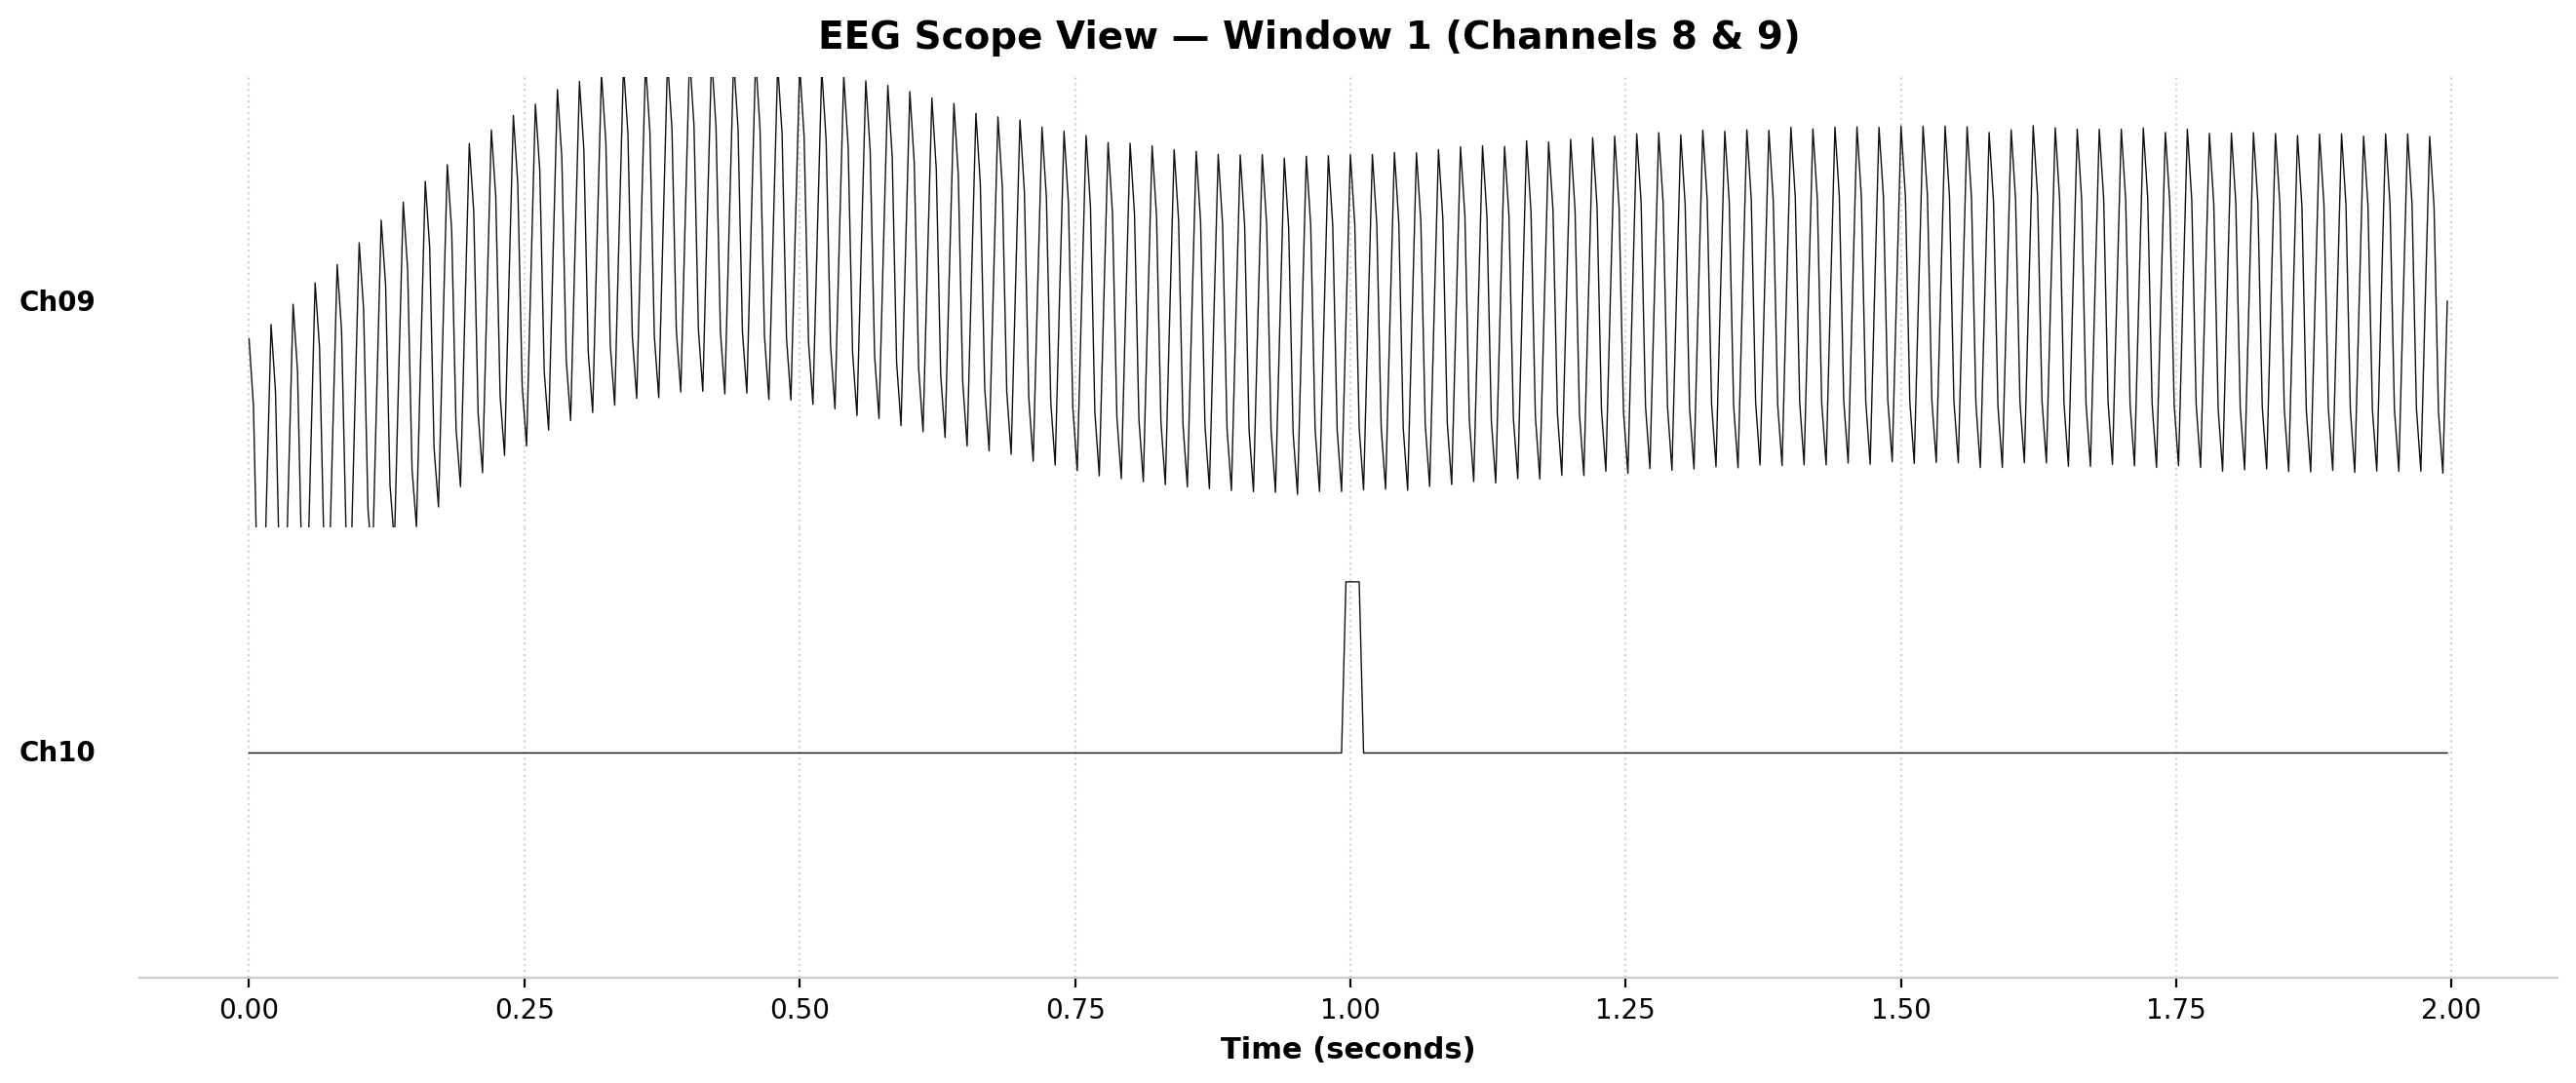

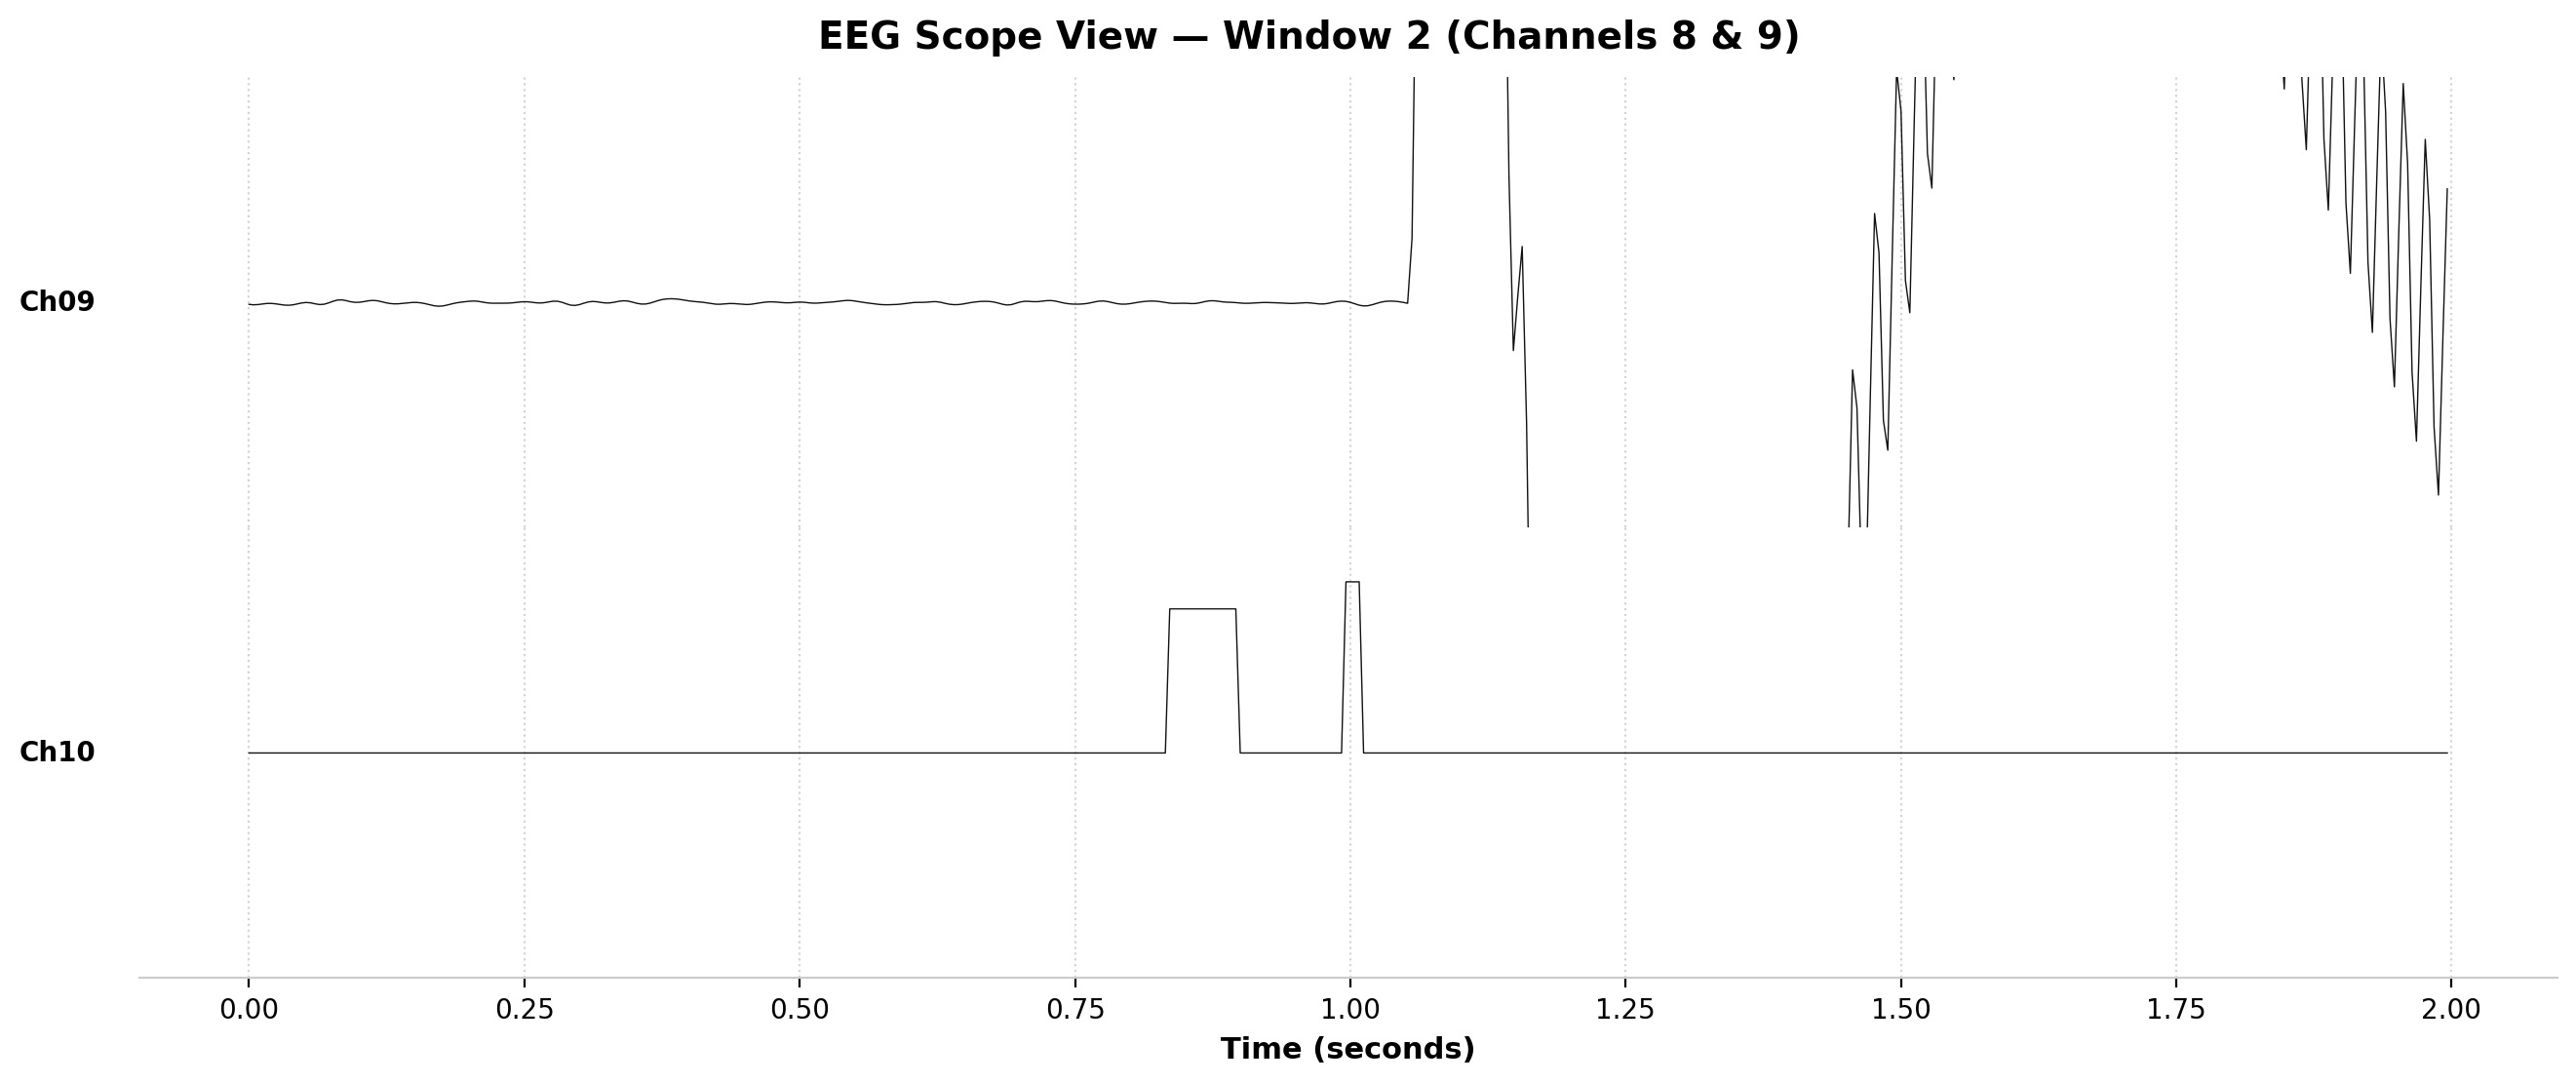

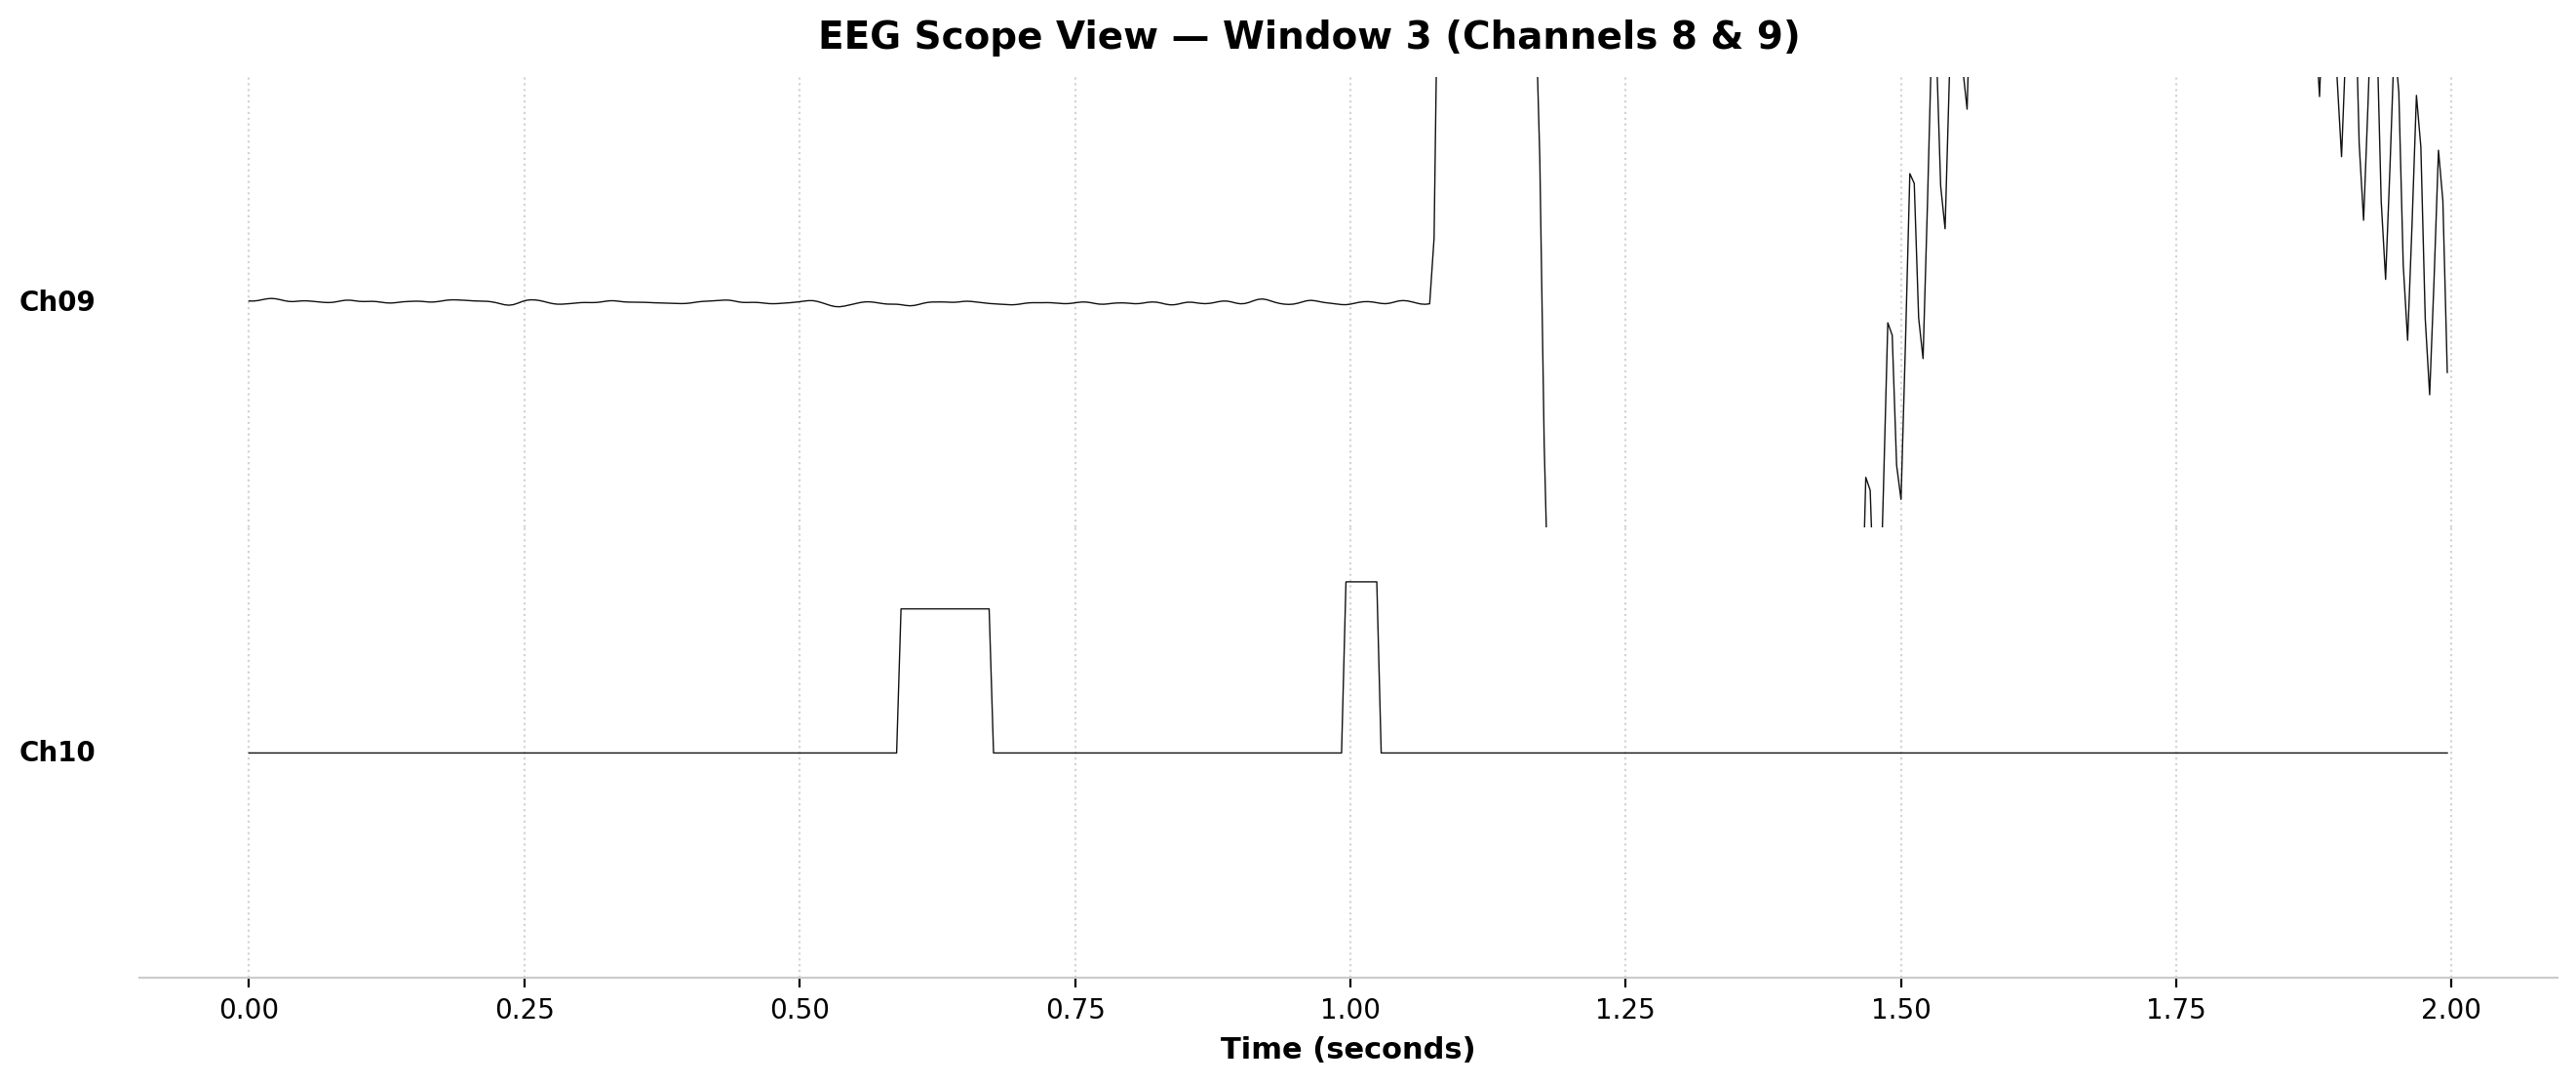

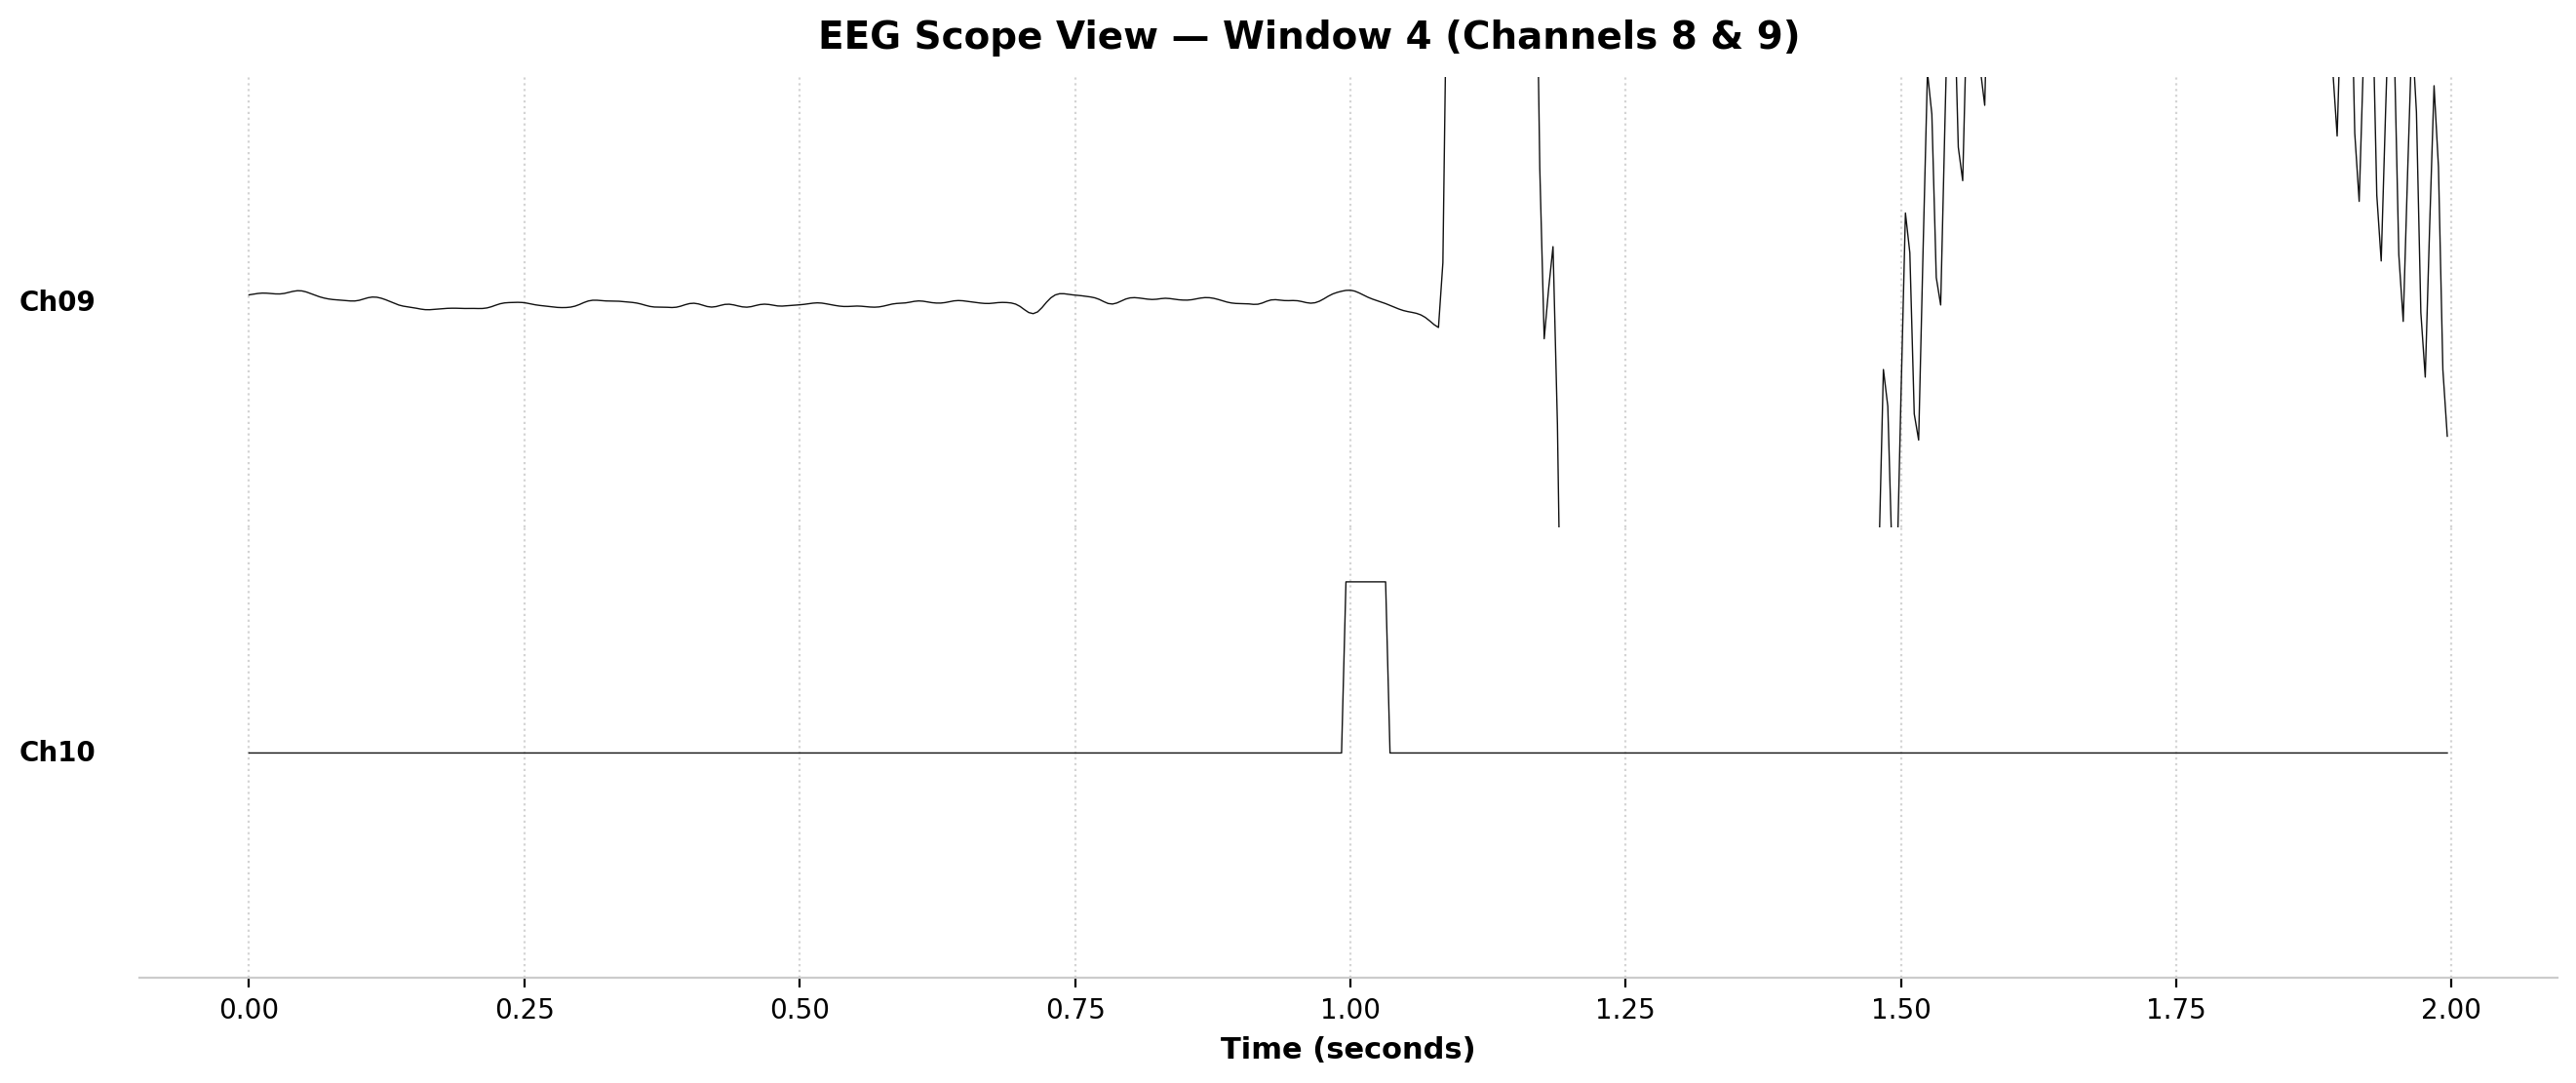

In [280]:
import numpy as np
import matplotlib.pyplot as plt

# small: shape (n_windows, n_times, 10)
n_windows  = small.shape[0]
n_times    = small.shape[1]
n_channels = small.shape[2]

AMPLITUDE_WINDOW = 50

# Time axis (assuming 250 Hz sampling)
fs = 250
time = np.arange(n_times) / fs

# Only plot channels 8 and 9 → indices 7 and 8
channels_to_plot = [8, 9]

for w in range(n_windows):
    fig, axes = plt.subplots(len(channels_to_plot), 1,
                             figsize=(16, 6), sharex=True, dpi=200)

    for ax_i, ch in enumerate(channels_to_plot):
        axes[ax_i].plot(time, small[w, :, ch], color='#111111', linewidth=0.5)
        axes[ax_i].set_ylim(-AMPLITUDE_WINDOW, AMPLITUDE_WINDOW)
        axes[ax_i].set_ylabel(f"Ch{ch+1:02d}", rotation=0, labelpad=30,
                              verticalalignment='center', fontweight='bold')
        axes[ax_i].grid(True, linestyle=':', alpha=0.5, color='#aaaaaa')
        axes[ax_i].set_yticks([])

        for spine in ['top', 'right', 'left', 'bottom']:
            axes[ax_i].spines[spine].set_visible(False)

    axes[-1].spines['bottom'].set_visible(True)
    axes[-1].spines['bottom'].set_color('#cccccc')
    axes[-1].set_xlabel('Time (seconds)', fontsize=11, fontweight='bold')

    plt.subplots_adjust(hspace=0.0)
    plt.suptitle(f'EEG Scope View — Window {w+1} (Channels 8 & 9)', 
                 fontsize=14, fontweight='bold', y=0.93)
    plt.show()


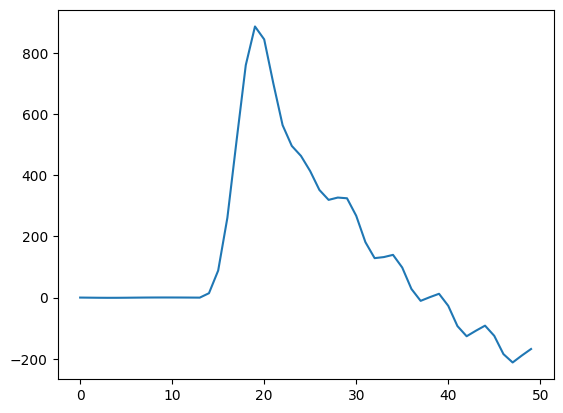

In [281]:
idx = 1
small[idx]
channel_8 = small[idx].T
plt.plot(channel_8[8][250:300])

In [282]:
pd.DataFrame(channel_8[8][250:280])

,0
0,0.062807
1,-0.258025
2,-0.571698
3,-0.734945
4,-0.684268
5,-0.460195
6,-0.160567
7,0.111096
8,0.283252
9,0.340238
